In [ ]:
import time
import copy
import json
import re
from typing import List, Optional, Set
from tqdm import tqdm
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F
from transformers import AutoModelForCausalLM, AutoTokenizer

# Newer transformers (>=4.43) returns DynamicCache instead of a plain tuple.
# We need helpers to convert between formats for direct tensor manipulation.
# IMPORTANT: The DynamicCache API has changed across versions.
# Let's first inspect what we're working with.
try:
    from transformers.cache_utils import DynamicCache
    HAS_DYNAMIC_CACHE = True
    print(f"DynamicCache available: True")

    # Inspect what attributes DynamicCache actually has in this version
    _test_cache = DynamicCache()
    print(f"DynamicCache attributes: {[a for a in dir(_test_cache) if not a.startswith('_')]}")
except ImportError:
    HAS_DYNAMIC_CACHE = False
    print(f"DynamicCache available: False (using legacy tuple format)")

DynamicCache available: True
DynamicCache attributes: ['batch_repeat_interleave', 'batch_select_indices', 'crop', 'early_initialization', 'get_mask_sizes', 'get_max_cache_shape', 'get_seq_length', 'is_compileable', 'is_initialized', 'is_sliding', 'layer_class_to_replicate', 'layers', 'max_batch_size', 'max_cache_len', 'offload', 'offloading', 'prefetch', 'reorder_cache', 'reset', 'update']


# 1) Text Generation

| Section | Topic | Key Question |
|---------|-------|-------------|
| 1 | Setup | Load a model and tokenizer |
| 2 | Next-token prediction | How does an LLM predict the next word? |
| 3 | Naive autoregressive generation | What happens when we generate token by token? |
| 4 | KV-Cache | How do we avoid redundant computation? |
| 5 | Sampling strategies | Greedy vs top-k vs top-p vs temperature |
| 6 | Batched generation | How do we process multiple prompts at once? |
| 7 | Continuous batching | How do production servers stay efficient? |
| 8 | Speculative decoding | How do we make generation 2-3x faster? |

In [ ]:
model_name = "openai-community/gpt2"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(model_name)
model.eval()

print(f"Model: {model_name}")
print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"Vocabulary size: {model.config.vocab_size}")
print(f"Embedding dim: {model.config.n_embd}")
print(f"Layers: {model.config.n_layer}")
print(f"Attention heads: {model.config.n_head}")

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: openai-community/gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model: openai-community/gpt2
Parameters: 124,439,808
Vocabulary size: 50257
Embedding dim: 768
Layers: 12
Attention heads: 12


## 1.1 Next-Token Prediction — The Atomic Unit of Generation

![](https://miro.medium.com/v2/resize:fit:1200/1*8TANZYj-I-w2lKK6RnUYRg.png)

Before we generate anything, let's understand what the model actually does
in a single forward pass.

When we feed a sequence of tokens into the model, it returns **logits** —
one vector of scores per input position, each with `vocab_size` entries.
The logits at position $i$ predict the token at position $i+1$.

For generation, we only care about the **last position's logits**,
because those predict what comes next after the entire input.

$$\text{input_ids} \;(1, \text{seq_len}) \;\xrightarrow{\text{model}}\; \text{logits} \;(1, \text{seq_len}, \text{vocab_size})$$

We take `logits[0, -1, :]` → a vector of 50,257 scores → pick the highest → that is our next token.



In [ ]:
prompt = "The quick brown fox jumped over the"
inputs = tokenizer(prompt, return_tensors="pt")

print("Token IDs:", inputs["input_ids"])
print("Decoded tokens:", [tokenizer.decode(t) for t in inputs["input_ids"][0]])
print(f"Input shape: {inputs['input_ids'].shape}")  # (1, seq_len)

# Single forward pass — the model sees all tokens at once
# input_ids (1, seq_len) -> logits (1, seq_len, vocab_size)
with torch.no_grad():
    logits = model(**inputs).logits

print(f"Output logits shape: {logits.shape}")

# The last position predicts the next token
# logits[0, -1, :] -> (vocab_size,)
last_logits = logits[0, -1, :]

# Greedy: pick the token with the highest score
next_token_id = last_logits.argmax()
print(f"\nGreedy next token: '{tokenizer.decode(next_token_id)}' (id={next_token_id.item()})")

# Let's also see the top-5 candidates with their probabilities
probs = F.softmax(last_logits, dim=-1)
top5 = torch.topk(probs, k=5)

print("\nTop-5 predictions:")
for prob, idx in zip(top5.values, top5.indices):
    print(f"  '{tokenizer.decode(idx)}' — {prob.item():.2%}")

Token IDs: tensor([[  464,  2068,  7586, 21831, 11687,   625,   262]])
Decoded tokens: ['The', ' quick', ' brown', ' fox', ' jumped', ' over', ' the']
Input shape: torch.Size([1, 7])
Output logits shape: torch.Size([1, 7, 50257])

Greedy next token: ' fence' (id=13990)

Top-5 predictions:
  ' fence' — 7.82%
  ' edge' — 4.73%
  ' railing' — 2.67%
  ' wall' — 2.41%
  ' table' — 2.02%


## 1.2 Naive Autoregressive Generation

![](https://cnassets.uk/notebooks/5_autoregressive_generation_files/autoregressive-generation-loop-diagram.png)

To generate multiple tokens, we repeat the prediction step in a loop.
The naive approach is simple:

1. Feed the full sequence into the model
2. Get the next token
3. Append it to the sequence
4. Feed the **entire** (now longer) sequence into the model again
5. Repeat

This works, but there is a problem: **every step recomputes attention
over all previous tokens**. The cost per step grows with sequence length,
and total cost grows **quadratically**.

For a sequence of length $n$, the attention cost at each step is $O(n)$.
Over $T$ generation steps, total cost is $O(n \cdot T + T^2)$.

In [ ]:
prompt = "The quick brown fox jumped over the"
inputs = tokenizer(prompt, return_tensors="pt")

generated_tokens = []
next_inputs = copy.deepcopy(inputs)
durations_no_cache = []

for step in range(20):
    t0 = time.time()

    # Full forward pass over the entire sequence every time
    # input_ids (1, seq_len + step) -> logits (1, seq_len + step, vocab_size)
    with torch.no_grad():
        logits = model(**next_inputs).logits

    next_token_id = logits[0, -1, :].argmax()
    durations_no_cache.append(time.time() - t0)

    # Append new token to the full sequence
    # (1, seq_len + step) + (1, 1) -> (1, seq_len + step + 1)
    next_inputs = {
        "input_ids": torch.cat(
            [next_inputs["input_ids"], next_token_id.reshape(1, 1)], dim=1
        ),
        "attention_mask": torch.cat(
            [next_inputs["attention_mask"], torch.tensor([[1]])], dim=1
        ),
    }
    generated_tokens.append(tokenizer.decode(next_token_id))

print(f"Generated: {' '.join(generated_tokens)}")
print(f"Total time: {sum(durations_no_cache):.2f}s")
print(f"First step: {durations_no_cache[0]*1000:.1f}ms, Last step: {durations_no_cache[-1]*1000:.1f}ms")

Generated:  fence  and  ran  to  the  other  side  of  the  fence .  He  was  about  to  run  when  he  saw  the
Total time: 5.14s
First step: 293.9ms, Last step: 447.7ms


## 1.3 KV-Cache — Avoiding Redundant Computation

![](https://miro.medium.com/v2/resize:fit:1400/1*uyuyOW1VBqmF5Gtv225XHQ.gif)

**The problem with naive generation**

At step 10, we recompute attention for tokens 1–9 even though they haven't
changed. This is pure waste.

**The solution: cache the Key and Value matrices**

In the attention mechanism, each layer computes:

$$\text{Attention}(Q, K, V) = \text{softmax}\!\left(\frac{QK^T}{\sqrt{d_k}}\right) V$$

The Key ($K$) and Value ($V$) matrices for all previous tokens don't change
when we add a new token. So we can **cache** them and only compute $Q$, $K$, $V$
for the new token, then concatenate.

This turns each decode step from $O(\text{seq\_len})$ to $O(1)$ in computation
(though the attention still reads the full cached $K$ and $V$).

---

**Two phases of generation**

| Phase | What happens | Cost |
|-------|-------------|------|
| **Prefill** | Process the entire prompt at once, build the initial KV-cache | $O(n^2)$ for prompt of length $n$ |
| **Decode** | Process one new token at a time, reuse and grow the cache | $O(n)$ per step (reading the cache) |

The prefill is compute-bound (lots of matrix multiplications).
The decode is memory-bound (reading large KV-cache tensors from memory).

This distinction matters a lot for optimization — and is the reason
speculative decoding works, as we will see in Section 8.

---

**KV-cache shape**

For GPT-2 with 12 layers and 12 heads (head_dim = 64):

`past_key_values` is a tuple of 12 layers, each containing:
- Key tensor:   `(batch, num_heads, cached_seq_len, head_dim)` = `(1, 12, seq_len, 64)`
- Value tensor: same shape

Each new decode step appends one position to `cached_seq_len`.



In [ ]:
def is_dynamic_cache(past_key_values):
    """Check if past_key_values is a DynamicCache object."""
    if not HAS_DYNAMIC_CACHE:
        return False
    return isinstance(past_key_values, DynamicCache)


def cache_to_tuple(past_key_values):
    """Convert DynamicCache -> tuple of (key, value) per layer.
    No-op if already a tuple/None.

    Handles multiple DynamicCache API versions:
    - Newer: cache.key_cache / cache.value_cache (list of tensors)
    - Older: iterate via cache[layer_idx] or cache.to_legacy_cache()
    """
    if past_key_values is None:
        return None
    if not is_dynamic_cache(past_key_values):
        return past_key_values

    # Method 1: to_legacy_cache() — cleanest if available
    if hasattr(past_key_values, "to_legacy_cache"):
        return past_key_values.to_legacy_cache()

    # Method 2: key_cache / value_cache attributes (newer versions)
    if hasattr(past_key_values, "key_cache"):
        return tuple(
            (past_key_values.key_cache[i], past_key_values.value_cache[i])
            for i in range(len(past_key_values.key_cache))
        )

    # Method 3: iterate directly (DynamicCache supports __iter__ in some versions)
    try:
        return tuple(past_key_values)
    except TypeError:
        pass

    # Method 4: index by layer
    try:
        num_layers = len(past_key_values)
        return tuple(past_key_values[i] for i in range(num_layers))
    except (TypeError, KeyError):
        pass

    raise TypeError(
        f"Cannot convert {type(past_key_values).__name__} to tuple. "
        f"Attributes: {[a for a in dir(past_key_values) if not a.startswith('_')]}"
    )


def tuple_to_cache(past_kv_tuple):
    """Convert tuple of (key, value) per layer -> DynamicCache.
    Returns the tuple as-is if DynamicCache is not available.
    """
    if past_kv_tuple is None:
        return None
    if not HAS_DYNAMIC_CACHE:
        return past_kv_tuple

    # Method 1: from_legacy_cache() — cleanest if available
    if hasattr(DynamicCache, "from_legacy_cache"):
        return DynamicCache.from_legacy_cache(past_kv_tuple)

    # Method 2: key_cache / value_cache direct assignment
    cache = DynamicCache()
    if hasattr(cache, "key_cache"):
        for k, v in past_kv_tuple:
            cache.key_cache.append(k)
            cache.value_cache.append(v)
        return cache

    # Method 3: use update() method
    if hasattr(cache, "update"):
        for layer_idx, (k, v) in enumerate(past_kv_tuple):
            cache.update(k, v, layer_idx)
        return cache

    raise TypeError(
        f"Cannot create DynamicCache from tuple. "
        f"DynamicCache methods: {[a for a in dir(cache) if not a.startswith('_')]}"
    )


# Quick test: verify round-trip conversion works
print("\nTesting cache conversion...")
_test_kv = tuple(
    (torch.randn(1, 12, 5, 64), torch.randn(1, 12, 5, 64))
    for _ in range(12)
)

if HAS_DYNAMIC_CACHE:
    _test_cache = tuple_to_cache(_test_kv)
    print(f"  tuple -> DynamicCache: OK (type={type(_test_cache).__name__})")
    _test_back = cache_to_tuple(_test_cache)
    print(f"  DynamicCache -> tuple: OK (layers={len(_test_back)}, shape={_test_back[0][0].shape})")
    assert len(_test_back) == 12
    assert _test_back[0][0].shape == (1, 12, 5, 64)
    print("  Round-trip: PASSED")
else:
    print("  Skipped (no DynamicCache)")



Testing cache conversion...
  tuple -> DynamicCache: OK (type=DynamicCache)
  DynamicCache -> tuple: OK (layers=12, shape=torch.Size([1, 12, 5, 64]))
  Round-trip: PASSED


**Working with Hugging Face's KV-Cache**

---

Hugging Face provides a `DynamicCache` class to manage KV-cache storage during generation. Instead of raw tuples of tensors, the model returns a `DynamicCache` object in `outputs.past_key_values` that grows automatically as new tokens are generated.

Internally, it stores one Key tensor and one Value tensor per layer, each with shape `(batch, num_heads, seq_len, head_dim)`. Every decode step appends one position to `seq_len`.

For simple generation, we just pass it straight back to the model — no extra handling needed. But for advanced operations like continuous batching (Section 7), we need to manually slice and pad the tensors inside the cache. So we define two small helpers: `cache_to_tuple()` extracts the raw tensors as a plain tuple we can manipulate, and `tuple_to_cache()` wraps them back into a `DynamicCache` before passing to the model.

transformers version: 5.0.0
DynamicCache available: True
DynamicCache attributes: ['batch_repeat_interleave', 'batch_select_indices', 'crop', 'early_initialization', 'get_mask_sizes', 'get_max_cache_shape', 'get_seq_length', 'is_compileable', 'is_initialized', 'is_sliding', 'layer_class_to_replicate', 'layers', 'max_batch_size', 'max_cache_len', 'offload', 'offloading', 'prefetch', 'reorder_cache', 'reset', 'update']

Testing cache conversion...
  tuple -> DynamicCache: OK (type=DynamicCache)
  DynamicCache -> tuple: OK (layers=12, shape=torch.Size([1, 12, 5, 64]))
  Round-trip: PASSED

Generated:  fence  and  ran  to  the  other  side  of  the  fence .  He  was  about  to  run  when  he  saw  the
Total time: 1.69s
Speedup vs no-cache: 3.0x

KV-cache type from model: DynamicCache
KV-cache structure:
  Layers: 12
  Entries per layer (K and V): 3
  Key shape: torch.Size([1, 12, 26, 64])


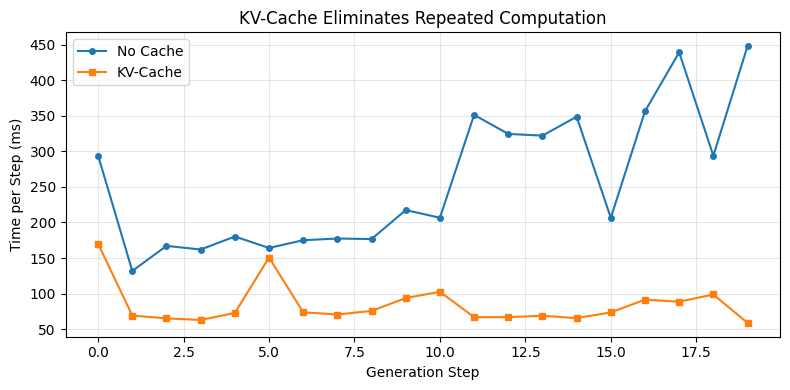

In [ ]:
bprompt = "The quick brown fox jumped over the"
inputs = tokenizer(prompt, return_tensors="pt")

generated_tokens = []
next_inputs = copy.deepcopy(inputs)
durations_cached = []

for step in range(20):
    t0 = time.time()

    with torch.no_grad():
        outputs = model(**next_inputs)

    next_token_id = outputs.logits[0, -1, :].argmax()
    past_kv = outputs.past_key_values  # Could be DynamicCache or tuple
    durations_cached.append(time.time() - t0)

    # With cache: only feed the NEW token, not the full sequence
    # We pass past_key_values directly — the model accepts both formats
    next_inputs = {
        "input_ids": next_token_id.reshape(1, 1),
        "attention_mask": torch.cat(
            [next_inputs["attention_mask"], torch.tensor([[1]])], dim=1
        ),
        "past_key_values": past_kv,
    }
    generated_tokens.append(tokenizer.decode(next_token_id))

print(f"\nGenerated: {' '.join(generated_tokens)}")
print(f"Total time: {sum(durations_cached):.2f}s")
print(f"Speedup vs no-cache: {sum(durations_no_cache)/sum(durations_cached):.1f}x")

# Inspect the cache structure
# Convert to tuple format so we can index into it for inspection
past_kv_tuple = cache_to_tuple(past_kv)
print(f"\nKV-cache type from model: {type(past_kv).__name__}")
print(f"KV-cache structure:")
print(f"  Layers: {len(past_kv_tuple)}")
print(f"  Entries per layer (K and V): {len(past_kv_tuple[0])}")
print(f"  Key shape: {past_kv_tuple[0][0].shape}")
# (1, 12, prompt_len + 20, 64) — grows by 1 each step

# Compare timing: cached is nearly flat, no-cache grows
plt.figure(figsize=(8, 4))
plt.plot([d * 1000 for d in durations_no_cache], label="No Cache", marker="o", markersize=4)
plt.plot([d * 1000 for d in durations_cached], label="KV-Cache", marker="s", markersize=4)
plt.xlabel("Generation Step")
plt.ylabel("Time per Step (ms)")
plt.legend()
plt.title("KV-Cache Eliminates Repeated Computation")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Why does KV-cache memory become a bottleneck in production? Let's do the math.

For every token, we store a Key and a Value vector for every attention head in every layer. The size of this cached data is:
`2 (Key & Value) × n_layers × n_heads × head_dim × 2 (bytes for FP16/BF16)`

Let's calculate the memory required for a single token, and then see how it scales up for a full batch in a production scenario.

## 1.4 Sampling Strategies

### 1.4.1 Greedy Decoding

![](https://media.geeksforgeeks.org/wp-content/uploads/20260203171616120129/top_p_sampling.webp)

![](https://miro.medium.com/v2/resize:fit:1400/1*HE6i-BjvPmfCxZJ5Ty7JXw.png)

So far we have used **greedy decoding**: always pick the highest-probability
token. This is deterministic and often repetitive.

In practice, we want to **sample** from the distribution to get diverse,
natural-sounding text. There are several knobs we can turn:

---

**Temperature**

Temperature rescales the logits before softmax:

$$p_i = \frac{\exp(z_i / T)}{\sum_j \exp(z_j / T)}$$

- $T = 1.0$: original distribution (default)
- $T < 1.0$: sharper distribution (more confident, less diverse)
- $T > 1.0$: flatter distribution (more random, more diverse)
- $T \to 0$: approaches greedy decoding

---

**Top-k sampling**

Only consider the $k$ highest-probability tokens. Set all others to $-\infty$
before sampling. This prevents the model from picking very unlikely tokens.

---

**Top-p (nucleus) sampling**

Sort tokens by probability, then keep the smallest set whose cumulative
probability exceeds $p$. This adapts dynamically — when the model is
confident, fewer tokens are kept; when uncertain, more are kept.

---

**In practice**, most systems combine temperature + top-p.
For example, Claude uses temperature with top-p as a safety net.

In [ ]:
def sample_next_token(
    logits: torch.Tensor,
    temperature: float = 1.0,
    top_k: int = 0,
    top_p: float = 1.0,
) -> torch.Tensor:
    """Sample a single token from logits with temperature, top-k, and top-p.

    Input:  logits (vocab_size,)
    Output: token_id (scalar tensor)
    """
    # --- Temperature scaling ---
    # logits (vocab_size,) -> scaled_logits (vocab_size,)
    if temperature != 1.0:
        logits = logits / temperature

    # --- Top-k filtering ---
    # Keep only the top-k logits, set rest to -inf
    if top_k > 0:
        top_k = min(top_k, logits.size(-1))
        # kth_value is the cutoff score
        kth_value = torch.topk(logits, top_k).values[-1]
        logits = torch.where(logits < kth_value, torch.tensor(float("-inf")), logits)

    # --- Top-p (nucleus) filtering ---
    # Keep the smallest set of tokens whose cumulative prob >= top_p
    if top_p < 1.0:
        sorted_logits, sorted_indices = torch.sort(logits, descending=True)
        cumulative_probs = torch.cumsum(F.softmax(sorted_logits, dim=-1), dim=-1)

        # Find where cumulative prob exceeds top_p
        # Shift right so we keep the token that crosses the threshold
        sorted_mask = cumulative_probs - F.softmax(sorted_logits, dim=-1) >= top_p
        sorted_logits[sorted_mask] = float("-inf")

        # Scatter back to original order
        logits = torch.zeros_like(logits).scatter(0, sorted_indices, sorted_logits)

    # --- Sample from the filtered distribution ---
    probs = F.softmax(logits, dim=-1)
    return torch.multinomial(probs, num_samples=1).squeeze()


# Let's see how different settings affect the same logits
prompt = "Once upon a time, there was a"
inputs = tokenizer(prompt, return_tensors="pt")

with torch.no_grad():
    logits = model(**inputs).logits[0, -1, :]  # (vocab_size,)

print(f"Prompt: '{prompt}'\n")

configs = [
    {"temperature": 1.0, "top_k": 0,  "top_p": 1.0,  "label": "Pure sampling (T=1.0)"},
    {"temperature": 0.3, "top_k": 0,  "top_p": 1.0,  "label": "Low temp (T=0.3)"},
    {"temperature": 1.0, "top_k": 10, "top_p": 1.0,  "label": "Top-k=10"},
    {"temperature": 1.0, "top_k": 0,  "top_p": 0.9,  "label": "Top-p=0.9"},
    {"temperature": 0.7, "top_k": 0,  "top_p": 0.9,  "label": "T=0.7 + top-p=0.9 (common)"},
]

for cfg in configs:
    label = cfg.pop("label")
    # Sample 8 times to show variation
    tokens = [sample_next_token(logits.clone(), **cfg) for _ in range(8)]
    words = [tokenizer.decode(t) for t in tokens]
    print(f"  {label}:")
    print(f"    → {words}\n")

Prompt: 'Once upon a time, there was a'

  Pure sampling (T=1.0):
    → [' feeling', ' room', ' gentleman', ' wicked', ' treaty', ' civilization', ' se', ' man']

  Low temp (T=0.3):
    → [' great', ' great', ' man', ' great', ' small', ' man', ' great', ' man']

  Top-k=10:
    → [' time', ' man', ' man', ' man', ' small', ' war', ' great', ' certain']

  Top-p=0.9:
    → [' point', ' mysterious', ' Red', ' new', ' huge', ' quarter', ' slight', ' woman']

  T=0.7 + top-p=0.9 (common):
    → [' man', ' certain', ' man', ' story', ' great', ' time', ' sense', ' time']



In [ ]:
# Full generation with sampling

def generate(
    model,
    tokenizer,
    prompt: str,
    max_new_tokens: int = 50,
    temperature: float = 1.0,
    top_k: int = 0,
    top_p: float = 1.0,
    greedy: bool = False,
) -> str:
    """Generate text with KV-cache and configurable sampling.

    This is our reference generation function — we will benchmark
    everything against it in later sections.
    """
    inputs = tokenizer(prompt, return_tensors="pt")
    generated_ids = inputs["input_ids"][0].tolist()
    next_inputs = inputs

    for _ in range(max_new_tokens):
        with torch.no_grad():
            outputs = model(**next_inputs)

        logits = outputs.logits[0, -1, :]  # (vocab_size,)

        if greedy:
            next_id = logits.argmax()
        else:
            next_id = sample_next_token(logits, temperature, top_k, top_p)

        generated_ids.append(next_id.item())

        # Stop at EOS
        if next_id.item() == tokenizer.eos_token_id:
            break

        # Feed only new token + cache
        # past_key_values can be DynamicCache or tuple — the model accepts both
        next_inputs = {
            "input_ids": next_id.reshape(1, 1),
            "attention_mask": torch.cat(
                [next_inputs["attention_mask"], torch.tensor([[1]])], dim=1
            ),
            "past_key_values": outputs.past_key_values,
        }

    return tokenizer.decode(generated_ids, skip_special_tokens=True)


# Demo different sampling strategies
prompt = "In a distant galaxy, scientists discovered"

print("Greedy:")
print(generate(model, tokenizer, prompt, max_new_tokens=40, greedy=True))
print()

print("T=0.7, top-p=0.9:")
print(generate(model, tokenizer, prompt, max_new_tokens=40, temperature=0.7, top_p=0.9))
print()

print("T=1.2, top-k=50 (more creative):")
print(generate(model, tokenizer, prompt, max_new_tokens=40, temperature=1.2, top_k=50))

Greedy:
In a distant galaxy, scientists discovered a new type of star, called a "supernova," that is about the size of a football field.

The supernova is a supernova that is about the size of a football field

T=0.7, top-p=0.9:
In a distant galaxy, scientists discovered a planet called Enceladus that was the first of its kind to be discovered.

The team of astronomers used the data to build a model of the planet, which they dubbed Ence

T=1.2, top-k=50 (more creative):
In a distant galaxy, scientists discovered billions of radio telescopes around the edges of Earth. The astronomers have yet to observe what might be the surface of an even larger black hole than us, if we do find any—perhaps even a neutron


### 1.4.2 Beam Search Decoding

![](https://towardsdatascience.com/wp-content/uploads/2021/04/1tEjhWqUgjX37VnT7gJN-4g.png)

So far, we have used greedy decoding (picking the single best token) or sampling. However, greedy decoding can lead to suboptimal sequences because a highly probable token might be hidden behind a low-probability one.

**Beam Search** keeps track of the $B$ (beam width) most probable sequences at each step. Instead of committing to the single best token, it explores multiple paths and eventually chooses the sequence with the highest overall probability.

1. Start with the initial prompt.
2. Generate the top $B$ next tokens to form $B$ hypotheses.
3. For each hypothesis, generate the next tokens and calculate the cumulative probability.
4. Keep only the top $B$ hypotheses overall.
5. Repeat until all beams generate the EOS token or hit the length limit.

In [ ]:
def beam_search_generation(model, tokenizer, prompt: str, beam_width: int = 3, max_new_tokens: int = 20):
    """A simplified beam search implementation."""
    inputs = tokenizer(prompt, return_tensors="pt")

    # Beams: list of tuples (sequence_tensor, log_probability)
    # For simplicity, we won't use KV-cache in this barebones example to keep the logic clear.
    # In practice, you MUST duplicate and manage the KV-cache for each beam.

    beams = [(inputs["input_ids"][0], 0.0)]

    for step in range(max_new_tokens):
        new_beams = []
        for seq, score in beams:
            # If the sequence ended, just carry it forward
            if seq[-1].item() == tokenizer.eos_token_id:
                new_beams.append((seq, score))
                continue

            with torch.no_grad():
                # input shape: (1, seq_len)
                outputs = model(seq.unsqueeze(0))
                logits = outputs.logits[0, -1, :]

            # Get log probabilities to avoid underflow
            log_probs = F.log_softmax(logits, dim=-1)

            # Get top B candidates for this beam
            top_log_probs, top_indices = torch.topk(log_probs, beam_width)

            for i in range(beam_width):
                new_seq = torch.cat([seq, top_indices[i].unsqueeze(0)])
                new_score = score + top_log_probs[i].item()
                new_beams.append((new_seq, new_score))

        # Sort all new beams by score and keep top B
        new_beams.sort(key=lambda x: x[1], reverse=True)
        beams = new_beams[:beam_width]

        # Early stopping if all top beams ended
        if all(b[0][-1].item() == tokenizer.eos_token_id for b in beams):
            break

    # Return the best sequence
    best_seq = beams[0][0]
    return tokenizer.decode(best_seq, skip_special_tokens=True)

print("Beam Search (Width=3):")
print(beam_search_generation(model, tokenizer, "In a distant galaxy, scientists discovered", beam_width=3, max_new_tokens=40))

## 1.5 Batched Generation
So far we process one prompt at a time. But GPUs are massively parallel —
they can process many sequences simultaneously with very little extra cost.

**The challenge: variable-length prompts**

If we have prompts of different lengths, we need to **pad** them to the same
length. For causal LMs, we use **left-padding** so that the last token
(which predicts the next word) aligns across all sequences.

```
Prompt A (5 tokens):  [PAD] [PAD] [PAD] the  cat  sat
Prompt B (8 tokens):  once  upon  a    time  the  cat  sat  down
```

The `attention_mask` tells the model to ignore pad tokens (0 = ignore, 1 = attend).

We also need `position_ids` because pad tokens should not occupy real positions.

```
Prompt A:  [PAD] [PAD] [PAD] the   cat   sat
attn_mask:   0     0     0     1     1     1
position:    1     1     1     0     1     2
```

---

**Throughput vs Latency tradeoff**

- Larger batch = more tokens per second (throughput increases)
- Larger batch = each individual request waits longer (latency increases)
- Production systems choose a batch size that balances both


In [ ]:
tokenizer.pad_token = tokenizer.eos_token
model.config.pad_token_id = model.config.eos_token_id
tokenizer.padding_side = "left"
tokenizer.truncation_side = "left"

In [ ]:
def compute_position_ids(attention_mask: torch.Tensor) -> torch.Tensor:
    """Derive position_ids from attention_mask, handling left-padding.

    Pad tokens get position 1 (arbitrary, ignored by attention_mask).
    Real tokens get sequential positions starting from 0.

    Input:  attention_mask (batch, seq_len) — 0 for pad, 1 for real
    Output: position_ids   (batch, seq_len) — sequential positions
    """
    pos = attention_mask.long().cumsum(-1) - 1
    pos.masked_fill_(attention_mask == 0, 1)
    return pos


def generate_batch(
    model,
    tokenizer,
    prompts: list,
    max_new_tokens: int = 10,
    greedy: bool = True,
) -> list:
    """Generate tokens for multiple prompts simultaneously.

    All prompts are padded to the same length and processed in parallel.
    """
    inputs = tokenizer(prompts, padding=True, return_tensors="pt")
    batch_size = inputs["input_ids"].shape[0]

    generated = [[] for _ in range(batch_size)]
    next_inputs = {**inputs, "position_ids": compute_position_ids(inputs["attention_mask"])}

    for _ in range(max_new_tokens):
        with torch.no_grad():
            outputs = model(**next_inputs)

        # (batch, seq_len, vocab_size) -> (batch,)
        if greedy:
            next_ids = outputs.logits[:, -1, :].argmax(dim=1)
        else:
            next_ids = torch.stack([
                sample_next_token(outputs.logits[i, -1, :])
                for i in range(batch_size)
            ])

        # Decode step: only new tokens + cache
        # past_key_values can be DynamicCache or tuple — model accepts both
        next_inputs = {
            "input_ids": next_ids.reshape(-1, 1),
            "position_ids": next_inputs["position_ids"][:, -1:] + 1,
            "attention_mask": torch.cat(
                [next_inputs["attention_mask"], torch.ones(batch_size, 1, dtype=torch.long)],
                dim=1,
            ),
            "past_key_values": outputs.past_key_values,
        }

        for i, tok in enumerate(tokenizer.batch_decode(next_ids)):
            generated[i].append(tok)

    return ["".join(toks) for toks in generated]

In [ ]:
# Test batched generation
prompts = [
    "The quick brown fox jumped over the",
    "The rain in Spain falls",
    "What comes up must",
]

inputs = tokenizer(prompts, padding=True, return_tensors="pt")
print("Padded input_ids shape:", inputs["input_ids"].shape)
print("Attention mask:\n", inputs["attention_mask"])
print("Position IDs:\n", compute_position_ids(inputs["attention_mask"]))

print("\nBatched generation:")
for prompt, gen in zip(prompts, generate_batch(model, tokenizer, prompts, max_new_tokens=10)):
    print(f"  {prompt} \033[91m{gen}\033[0m")

Padded input_ids shape: torch.Size([3, 7])
Attention mask:
 tensor([[1, 1, 1, 1, 1, 1, 1],
        [0, 0, 1, 1, 1, 1, 1],
        [0, 0, 0, 1, 1, 1, 1]])
Position IDs:
 tensor([[0, 1, 2, 3, 4, 5, 6],
        [1, 1, 0, 1, 2, 3, 4],
        [1, 1, 1, 0, 1, 2, 3]])

Batched generation:
  The quick brown fox jumped over the  fence on be and the a ran first good to day idea the of. other the
 side month
 of," the andI fence the think
  The rain in Spain falls 
  What comes up must 


Batch   1:    15.0 tok/s | latency 66.9 ms/step
Batch   2:    13.6 tok/s | latency 147.1 ms/step
Batch   4:    15.2 tok/s | latency 263.9 ms/step
Batch   8:    38.8 tok/s | latency 206.2 ms/step
Batch  16:    77.3 tok/s | latency 207.0 ms/step
Batch  32:   145.2 tok/s | latency 220.4 ms/step
Batch  64:   192.1 tok/s | latency 333.2 ms/step


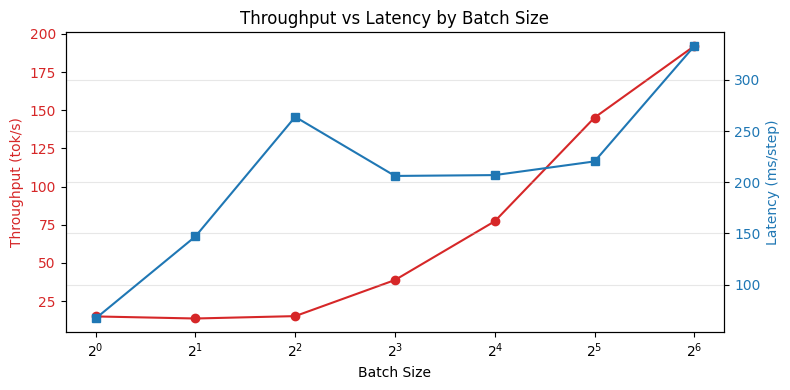

In [ ]:
max_tokens = 10
batch_sizes = [1, 2, 4, 8, 16, 32, 64]
throughputs, latencies = [], []

for bs in batch_sizes:
    batch_prompts = [prompts[i % len(prompts)] for i in range(bs)]

    t0 = time.time()
    generate_batch(model, tokenizer, batch_prompts, max_new_tokens=max_tokens)
    duration = time.time() - t0

    throughput = bs * max_tokens / duration
    latency = duration / max_tokens
    throughputs.append(throughput)
    latencies.append(latency)
    print(f"Batch {bs:>3d}: {throughput:>7.1f} tok/s | latency {latency*1000:.1f} ms/step")

# Dual-axis plot
fig, ax1 = plt.subplots(figsize=(8, 4))
ax1.set_xlabel("Batch Size")
ax1.set_ylabel("Throughput (tok/s)", color="tab:red")
ax1.plot(batch_sizes, throughputs, color="tab:red", marker="o")
ax1.tick_params(axis="y", labelcolor="tab:red")
ax1.set_xscale("log", base=2)

ax2 = ax1.twinx()
ax2.set_ylabel("Latency (ms/step)", color="tab:blue")
ax2.plot(batch_sizes, [l * 1000 for l in latencies], color="tab:blue", marker="s")
ax2.tick_params(axis="y", labelcolor="tab:blue")

plt.title("Throughput vs Latency by Batch Size")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 1.6 Continuous Batching

![](https://miro.medium.com/v2/resize:fit:1400/1*DvnBjrG6ivImZNNzeCbE9A.png)

**The problem with static batching**

In a static batch, all sequences must generate the same number of tokens.
If one sequence needs 100 tokens and the rest need 10, the GPU sits idle
for 90 steps while the short sequences are already done (padded with
useless tokens).

**Continuous batching solves this**

The idea is simple:
1. When a sequence finishes, remove it from the batch immediately
2. Insert a new request from the queue into the freed slot
3. The GPU stays fully utilized at all times

This is how production serving frameworks (vLLM, SGLang, TensorRT-LLM)
work under the hood. It is especially important when request lengths
vary a lot — which they do in practice.

---

**Implementation details**

Merging a new request into an existing batch requires:
- Prefilling the new request to build its KV-cache
- Padding the KV-caches to the same sequence length
- Concatenating along the batch dimension

We also trim shared leading padding to save memory.

In [ ]:
def _get_kv_pairs(cache_tuple):
    """Extract (key, value) pairs from cache, handling 2-element or 3-element tuples.

    Some transformers versions return (key, value) per layer.
    Others return (key, value, sliding_window_info) per layer.
    We only need key and value for our manipulation.
    """
    pairs = []
    for layer in cache_tuple:
        if len(layer) >= 2:
            pairs.append((layer[0], layer[1]))
        else:
            raise ValueError(f"Unexpected cache layer with {len(layer)} elements")
    return pairs


def _rebuild_cache_layers(kv_pairs, original_cache):
    """Rebuild cache layers, preserving extra elements (like sliding window) if present."""
    rebuilt = []
    for i, (k, v) in enumerate(kv_pairs):
        if len(original_cache[i]) > 2:
            # Preserve extra elements from the original (e.g., sliding window tensors)
            extras = original_cache[i][2:]
            rebuilt.append((k, v) + extras)
        else:
            rebuilt.append((k, v))
    return tuple(rebuilt)


def init_batch(tokenizer, model, requests):
    """Prefill: tokenize a list of (prompt, max_tokens) and run one forward pass."""
    batch_prompts = [r[0] for r in requests]
    inputs = tokenizer(batch_prompts, padding=True, return_tensors="pt")
    inputs["position_ids"] = compute_position_ids(inputs["attention_mask"])

    with torch.no_grad():
        outputs = model(**inputs)

    next_ids = outputs.logits[:, -1, :].argmax(dim=1)
    next_tokens = tokenizer.batch_decode(next_ids)

    past_kv = cache_to_tuple(outputs.past_key_values)

    return {
        "input_ids": next_ids.reshape(-1, 1),
        "position_ids": inputs["position_ids"][:, -1:] + 1,
        "attention_mask": torch.cat(
            [inputs["attention_mask"], torch.ones(len(requests), 1, dtype=torch.long)],
            dim=1,
        ),
        "past_key_values": past_kv,
        "responses": [p + t for p, t in zip(batch_prompts, next_tokens)],
        "tokens_remaining": [r[1] - 1 for r in requests],
    }


def decode_one_step(model, tokenizer, batch):
    """Run one decode step for the whole batch."""
    past_kv_for_model = tuple_to_cache(batch["past_key_values"])

    model_inputs = {
        "input_ids": batch["input_ids"],
        "position_ids": batch["position_ids"],
        "attention_mask": batch["attention_mask"],
        "past_key_values": past_kv_for_model,
    }

    with torch.no_grad():
        outputs = model(**model_inputs)

    next_ids = outputs.logits[:, -1, :].argmax(dim=1)
    next_tokens = tokenizer.batch_decode(next_ids)

    past_kv = cache_to_tuple(outputs.past_key_values)

    return {
        "input_ids": next_ids.reshape(-1, 1),
        "position_ids": batch["position_ids"][:, -1:] + 1,
        "attention_mask": torch.cat(
            [batch["attention_mask"], torch.ones(next_ids.shape[0], 1, dtype=torch.long)],
            dim=1,
        ),
        "past_key_values": past_kv,
        "responses": [r + t for r, t in zip(batch["responses"], next_tokens)],
        "tokens_remaining": [n - 1 for n in batch["tokens_remaining"]],
    }


def merge_batches(b1, b2):
    """Merge two batches by padding KV-caches to equal length."""
    a1, a2 = b1["attention_mask"], b2["attention_mask"]
    max_len = max(a1.shape[1], a2.shape[1])
    pad1, pad2 = max_len - a1.shape[1], max_len - a2.shape[1]

    # Left-pad attention masks
    a1 = F.pad(a1, (pad1, 0), value=0)
    a2 = F.pad(a2, (pad2, 0), value=0)

    # Extract just the K, V tensors (ignoring any extra elements)
    kv1 = _get_kv_pairs(b1["past_key_values"])
    kv2 = _get_kv_pairs(b2["past_key_values"])

    # Left-pad KV-cache on sequence dimension (dim=2), concat on batch dimension (dim=0)
    # key/value shape: (batch, heads, seq_len, head_dim)
    # F.pad(k, (0, 0, pad, 0)) pads seq_len dim on the left with zeros
    merged_kv_pairs = [
        (
            torch.cat([F.pad(k1, (0, 0, pad1, 0)), F.pad(k2, (0, 0, pad2, 0))]),
            torch.cat([F.pad(v1, (0, 0, pad1, 0)), F.pad(v2, (0, 0, pad2, 0))]),
        )
        for (k1, v1), (k2, v2) in zip(kv1, kv2)
    ]

    # Rebuild with any extra elements from the original cache structure
    merged_kv = _rebuild_cache_layers(merged_kv_pairs, b1["past_key_values"])

    return {
        "input_ids": torch.cat([b1["input_ids"], b2["input_ids"]]),
        "position_ids": torch.cat([b1["position_ids"], b2["position_ids"]]),
        "attention_mask": torch.cat([a1, a2]),
        "past_key_values": merged_kv,
        "responses": b1["responses"] + b2["responses"],
        "tokens_remaining": b1["tokens_remaining"] + b2["tokens_remaining"],
    }


def filter_batch(batch):
    """Remove completed sequences and trim shared leading padding."""
    done_indices = [i for i, n in enumerate(batch["tokens_remaining"]) if n <= 0]
    keep = torch.ones(batch["input_ids"].size(0), dtype=torch.bool)
    keep[done_indices] = False

    if keep.sum() == 0:
        return {
            "input_ids": torch.empty(0, 1, dtype=torch.long),
            "position_ids": torch.empty(0, 1, dtype=torch.long),
            "attention_mask": torch.empty(0, 0, dtype=torch.long),
            "past_key_values": batch["past_key_values"],
            "responses": [],
            "tokens_remaining": [],
        }, done_indices

    attn = batch["attention_mask"][keep]

    # Filter KV-cache along batch dimension, handling any cache structure
    kv_pairs = _get_kv_pairs(batch["past_key_values"])
    filtered_pairs = [(k[keep], v[keep]) for k, v in kv_pairs]

    # Trim shared leading padding to save memory
    leading_zeros = (attn == 0).cumprod(dim=1).sum(dim=1)
    offset = leading_zeros.min().item()
    if offset > 0:
        attn = attn[:, offset:]
        filtered_pairs = [
            (k[:, :, offset:, :], v[:, :, offset:, :])
            for k, v in filtered_pairs
        ]

    # Rebuild with any extra elements from original cache
    filtered_kv = _rebuild_cache_layers(filtered_pairs, batch["past_key_values"])

    return {
        "input_ids": batch["input_ids"][keep],
        "position_ids": batch["position_ids"][keep],
        "attention_mask": attn,
        "past_key_values": filtered_kv,
        "responses": [r for i, r in enumerate(batch["responses"]) if i not in done_indices],
        "tokens_remaining": [n for i, n in enumerate(batch["tokens_remaining"]) if i not in done_indices],
    }, done_indices

In [ ]:
queue_size = 32
batch_size = 8

# Create a realistic workload: one slow request (100 tokens) per batch,
# rest are fast (10 tokens). Static batching wastes compute on the fast ones.
def make_queue():
    return [
        (prompts[i % len(prompts)], 100 if i % batch_size == 0 else 10)
        for i in range(queue_size)
    ]

# --- Static batching ---
request_queue = make_queue()
batches = [request_queue[i:i + batch_size] for i in range(0, queue_size, batch_size)]

t0 = time.time()
for b in batches:
    max_tok = max(r[1] for r in b)
    batch_prompts = [r[0] for r in b]
    generate_batch(model, tokenizer, batch_prompts, max_new_tokens=max_tok)
static_time = time.time() - t0
print(f"Static batching:     {static_time:.2f}s")

# --- Continuous batching ---
request_queue = make_queue()
completed = 0

t0 = time.time()
cached_batch = init_batch(tokenizer, model, request_queue[:batch_size])
request_queue = request_queue[batch_size:]

while request_queue or cached_batch["input_ids"].size(0) > 0:
    # Fill spare capacity
    capacity = batch_size - cached_batch["input_ids"].size(0)
    if capacity > 0 and request_queue:
        new_batch = init_batch(tokenizer, model, request_queue[:capacity])
        request_queue = request_queue[capacity:]
        cached_batch = merge_batches(cached_batch, new_batch)

    # Decode one step
    cached_batch = decode_one_step(model, tokenizer, cached_batch)

    # Evict finished sequences
    cached_batch, removed = filter_batch(cached_batch)
    completed += len(removed)

continuous_time = time.time() - t0
print(f"Continuous batching: {continuous_time:.2f}s")
print(f"Speedup: {static_time / continuous_time:.2f}x")
print(f"Completed: {completed} requests")

## 1.7 Speculative Decoding

![](https://media.licdn.com/dms/image/v2/D5612AQEXlGkcvw4NLQ/article-cover_image-shrink_720_1280/B56ZiNwaknG0AI-/0/1754724947698?e=2147483647&v=beta&t=tJ8zA2QrsGSvmkARnmMfB-4X3xgQb1n0ccxE6CLX6dg)

**The core problem: LLM decode steps are memory-bound**

During the decode phase, each step generates just **one** token.
The GPU loads the entire model's weights and KV-cache from memory,
does a tiny amount of computation, and produces a single token.
The GPU's compute units are mostly idle — we are bottlenecked by
**memory bandwidth**, not compute.

This means: a forward pass that processes 1 token takes almost the
same time as one that processes 5 tokens. The GPU is already loading
all the weights anyway — processing a few more tokens in parallel
adds negligible cost.

**Speculative decoding exploits this.**

---

**How it works**

1. A small, fast **draft model** guesses the next $K$ tokens quickly
2. The large **target model** verifies all $K$ guesses in a **single** forward pass
3. If a guess is correct, we accept it (free tokens!)
4. If a guess is wrong, we reject it and use the target model's prediction instead
5. We always get at least 1 token per target forward pass, and up to $K+1$

---

**Why does verification work in one pass?**

Remember: the target model outputs logits for **every** position in the input.
If we feed it the draft's $K$ guesses as input, the target model simultaneously
computes what it would have predicted at each of those positions.

At position $i$, we compare:
- What the draft predicted: `draft_tokens[i]`
- What the target would have predicted: `argmax(target_logits[i])`

If they match → accept. If they don't → reject and take the target's token.
Once we reject at position $i$, we discard everything after $i$.

---

**The math: why this is always correct**

For greedy decoding, speculative decoding produces **exactly** the same output
as running the target model alone. This is because we only accept a draft token
when the target model agrees. There is **zero** quality loss — only speed gain.

For sampling, there is a more sophisticated acceptance criterion based on
rejection sampling that preserves the target model's exact distribution.
We will implement the greedy version first, which is simpler to understand.

---

**When does it help?**

| Scenario | Speedup | Why |
|----------|---------|-----|
| Predictable text (code, JSON, templates) | High (2-3x) | Draft model guesses correctly most of the time |
| Creative writing | Moderate (1.3-1.8x) | Harder to predict, more rejections |
| Very short outputs (<10 tokens) | Minimal | Overhead of running draft model isn't amortized |
| Large batch sizes (>8) | Diminishing | GPU is already compute-saturated from batching |

---

**Our setup**

We will use two GPT-2 models:
- **Target model**: GPT-2 (124M) — the model we want correct output from
- **Draft model**: GPT-2 (124M) with a distilled/smaller configuration

In production, typical pairings are:
- Llama 3.1-70B (target) + Llama 3.2-1B (draft)
- GPT-4 (target) + GPT-3.5 (draft)

The draft model should be much faster than the target, and from the same
"family" so its predictions roughly align with the target's.


In [ ]:
target_model = model  # GPT-2 124M (already loaded)
target_model.eval()

# Load a second copy as the "draft model"
# In real usage this would be a smaller model like distilgpt2
draft_model = AutoModelForCausalLM.from_pretrained("distilgpt2")
draft_model.eval()

print(f"Target model: {sum(p.numel() for p in target_model.parameters()):,} params")
print(f"Draft model:  {sum(p.numel() for p in draft_model.parameters()):,} params")

config.json:   0%|          | 0.00/762 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/353M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: distilgpt2
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
transformer.h.{0, 1, 2, 3, 4, 5}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

Target model: 124,439,808 params
Draft model:  81,912,576 params


In [ ]:
@torch.no_grad()
def speculative_decode(
    target_model,
    draft_model,
    tokenizer,
    prompt: str,
    max_new_tokens: int = 50,
    K: int = 4,
) -> dict:
    """Speculative decoding with greedy verification.

    Args:
        target_model: The large model we want correct output from
        draft_model:  The small, fast model that proposes candidate tokens
        K:            Number of tokens the draft model proposes per step

    Returns:
        dict with generated text, timing info, and acceptance statistics
    """
    input_ids = tokenizer(prompt, return_tensors="pt")["input_ids"]  # (1, prompt_len)

    total_generated = 0
    total_accepted = 0
    total_draft_time = 0.0
    total_verify_time = 0.0
    draft_iterations = 0

    while total_generated < max_new_tokens:
        # =====================================================================
        # Step 1: DRAFT — the small model proposes K candidate tokens
        # =====================================================================
        draft_start = time.time()

        draft_input_ids = input_ids.clone()
        draft_tokens = []

        for _ in range(K):
            draft_logits = draft_model(draft_input_ids).logits  # (1, seq, vocab)
            next_token = draft_logits[0, -1, :].argmax().unsqueeze(0).unsqueeze(0)  # (1, 1)
            draft_tokens.append(next_token.item())
            # Append and continue drafting
            draft_input_ids = torch.cat([draft_input_ids, next_token], dim=1)  # (1, seq+1)

        total_draft_time += time.time() - draft_start
        draft_iterations += 1

        # draft_tokens: list of K token ids
        draft_tensor = torch.tensor([draft_tokens])  # (1, K)

        # =====================================================================
        # Step 2: VERIFY — the target model checks all K tokens in ONE pass
        # =====================================================================
        verify_start = time.time()

        # Feed original input + all K draft tokens to target model
        # (1, prompt_len + K) -> logits (1, prompt_len + K, vocab_size)
        verify_input = torch.cat([input_ids, draft_tensor], dim=1)
        target_logits = target_model(verify_input).logits

        # The target model's prediction at position i is what it thinks
        # token i+1 should be. We check positions corresponding to our drafts.
        #
        # target_logits[0, prompt_len - 1, :] -> what target predicts for first draft position
        # target_logits[0, prompt_len, :]     -> what target predicts for second draft position
        # ...and so on
        prompt_len = input_ids.shape[1]

        total_verify_time += time.time() - verify_start

        # =====================================================================
        # Step 3: ACCEPT/REJECT — compare draft with target predictions
        # =====================================================================
        n_accepted = 0
        for i in range(K):
            target_prediction = target_logits[0, prompt_len - 1 + i, :].argmax().item()

            if draft_tokens[i] == target_prediction:
                # Draft was correct — accept this token for free!
                n_accepted += 1
            else:
                # Draft was wrong — take the target's prediction instead
                # and discard all remaining draft tokens
                break

        # We always get at least 1 token: either the last accepted draft token + 1,
        # or the target's correction at the first rejection point
        if n_accepted == K:
            # All K drafts accepted! Bonus: we also get the target's prediction
            # for position K+1 (the token after all drafts)
            bonus_token = target_logits[0, prompt_len + K - 1, :].argmax().item()
            accepted_tokens = draft_tokens + [bonus_token]
        else:
            # Accepted some, then the target's correction
            target_token = target_logits[0, prompt_len - 1 + n_accepted, :].argmax().item()
            accepted_tokens = draft_tokens[:n_accepted] + [target_token]

        # Append accepted tokens to the sequence
        new_tokens = torch.tensor([accepted_tokens])  # (1, n_accepted + 1)
        input_ids = torch.cat([input_ids, new_tokens], dim=1)

        total_accepted += n_accepted
        total_generated += len(accepted_tokens)

        # Check for EOS
        if tokenizer.eos_token_id in accepted_tokens:
            break

    # Decode the full sequence
    generated_text = tokenizer.decode(input_ids[0], skip_special_tokens=True)

    return {
        "text": generated_text,
        "total_tokens": total_generated,
        "accepted_draft_tokens": total_accepted,
        "draft_iterations": draft_iterations,
        "acceptance_rate": total_accepted / (draft_iterations * K) if draft_iterations > 0 else 0,
        "avg_tokens_per_step": total_generated / draft_iterations if draft_iterations > 0 else 0,
        "draft_time": total_draft_time,
        "verify_time": total_verify_time,
        "total_time": total_draft_time + total_verify_time,
    }

In [ ]:
prompt = "The quick brown fox jumped over the"
max_tokens = 40

# --- Standard generation (target model only) ---
t0 = time.time()
standard_text = generate(target_model, tokenizer, prompt, max_new_tokens=max_tokens, greedy=True)
standard_time = time.time() - t0

# --- Speculative decoding ---
spec_result = speculative_decode(
    target_model, draft_model, tokenizer, prompt, max_new_tokens=max_tokens, K=4
)

print("Standard generation:")
print(f"  Text: {standard_text}")
print(f"  Time: {standard_time:.3f}s")
print()

print("Speculative decoding:")
print(f"  Text: {spec_result['text']}")
print(f"  Time: {spec_result['total_time']:.3f}s")
print(f"  Draft time:  {spec_result['draft_time']:.3f}s")
print(f"  Verify time: {spec_result['verify_time']:.3f}s")
print(f"  Acceptance rate: {spec_result['acceptance_rate']:.1%}")
print(f"  Avg tokens per target call: {spec_result['avg_tokens_per_step']:.1f}")
print(f"  Draft iterations (target forward passes): {spec_result['draft_iterations']}")
print()

# Verify: greedy speculative decoding produces EXACTLY the same output
# (This is the key guarantee — zero quality loss)
if standard_text == spec_result["text"]:
    print("Output matches standard generation exactly.")
else:
    # Minor differences can occur due to the final token boundary
    print("Note: Minor difference at boundary (expected for max_tokens cutoff)")
    print(f"  Standard length: {len(standard_text)}")
    print(f"  Speculative length: {len(spec_result['text'])}")

Standard generation:
  Text: The quick brown fox jumped over the fence and ran to the other side of the fence. He was about to run when he saw the fox. He ran to the other side of the fence and ran to the other side of the fence
  Time: 2.299s

Speculative decoding:
  Text: The quick brown fox jumped over the fence and ran to the other side of the fence. He was about to run when he saw the fox. He ran to the other side of the fence and ran to the other side of the fence. He ran to
  Time: 6.693s
  Draft time:  4.838s
  Verify time: 1.855s
  Acceptance rate: 66.7%
  Avg tokens per target call: 3.7
  Draft iterations (target forward passes): 12

Note: Minor difference at boundary (expected for max_tokens cutoff)
  Standard length: 199
  Speculative length: 210


Benchmarking speculative decoding with different K values...

Baseline (no speculation): 6.437s | 9.3 tok/s
K=1: 11.594s | accept=82% | avg_tok/step=1.8 | speedup=0.56x
K=2: 18.893s | accept=70% | avg_tok/step=2.4 | speedup=0.34x
K=3: 12.953s | accept=62% | avg_tok/step=2.9 | speedup=0.50x
K=4: 12.883s | accept=55% | avg_tok/step=3.2 | speedup=0.50x
K=5: 14.386s | accept=47% | avg_tok/step=3.3 | speedup=0.45x
K=6: 15.326s | accept=46% | avg_tok/step=3.8 | speedup=0.42x
K=8: 17.069s | accept=44% | avg_tok/step=4.5 | speedup=0.38x


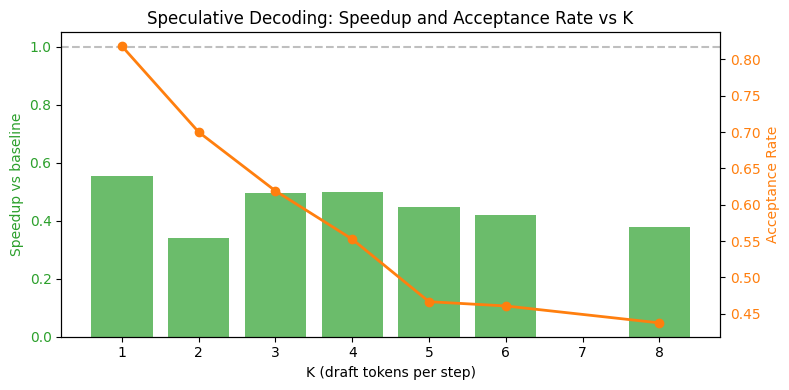

In [ ]:
print("Benchmarking speculative decoding with different K values...\n")

prompt = "In a galaxy far far away, there was a civilization that"
max_tokens = 60

# Baseline
t0 = time.time()
baseline_text = generate(target_model, tokenizer, prompt, max_new_tokens=max_tokens, greedy=True)
baseline_time = time.time() - t0
print(f"Baseline (no speculation): {baseline_time:.3f}s | {max_tokens/baseline_time:.1f} tok/s")

results = []
for k in [1, 2, 3, 4, 5, 6, 8]:
    result = speculative_decode(
        target_model, draft_model, tokenizer, prompt,
        max_new_tokens=max_tokens, K=k
    )
    speedup = baseline_time / result["total_time"]
    results.append((k, result, speedup))
    print(
        f"K={k}: {result['total_time']:.3f}s | "
        f"accept={result['acceptance_rate']:.0%} | "
        f"avg_tok/step={result['avg_tokens_per_step']:.1f} | "
        f"speedup={speedup:.2f}x"
    )

# Plot speedup vs K
ks = [r[0] for r in results]
speedups = [r[2] for r in results]
accept_rates = [r[1]["acceptance_rate"] for r in results]

fig, ax1 = plt.subplots(figsize=(8, 4))
ax1.set_xlabel("K (draft tokens per step)")
ax1.set_ylabel("Speedup vs baseline", color="tab:green")
ax1.bar(ks, speedups, color="tab:green", alpha=0.7)
ax1.axhline(y=1.0, color="gray", linestyle="--", alpha=0.5, label="baseline")
ax1.tick_params(axis="y", labelcolor="tab:green")

ax2 = ax1.twinx()
ax2.set_ylabel("Acceptance Rate", color="tab:orange")
ax2.plot(ks, accept_rates, color="tab:orange", marker="o", linewidth=2)
ax2.tick_params(axis="y", labelcolor="tab:orange")

plt.title("Speculative Decoding: Speedup and Acceptance Rate vs K")
plt.tight_layout()
plt.show()

## 1.8 Guided Generation — Constrained Decoding

In the generation notebook, we sampled tokens freely — the model could output
anything. In practice, we often need the output in a specific format:
valid JSON, one of a fixed set of choices, or a string matching a pattern.

**The problem**: Even well-trained models sometimes produce invalid JSON —
a missing quote, an extra comma, text before or after the JSON block.
Parsing fails, your application crashes.

**The solution**: At each generation step, before sampling, we **mask out**
every token that would break the required format. The model can only choose
from tokens that keep the output valid. This gives a 100% format guarantee
with zero post-processing.

In [ ]:
model_name = "openai-community/gpt2"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(model_name)
model.eval()

if tokenizer.pad_token_id is None:
    tokenizer.pad_token_id = tokenizer.eos_token_id

# Build a reverse mapping: token_id → decoded string
# We need this to check which tokens are "legal" at each step
id_to_token = {i: tokenizer.decode([i]) for i in range(tokenizer.vocab_size)}

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: openai-community/gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [ ]:
def generate_constrained(
    model,
    tokenizer,
    prompt: str,
    token_mask_fn,
    max_new_tokens: int = 50,
    temperature: float = 1.0,
) -> str:
    """Generate text with a token-level constraint applied at every step.

    At each step:
    1. Get logits from the model
    2. Call token_mask_fn(generated_so_far) → constraint mask
    3. Add mask to logits (forbidden tokens get probability ≈ 0)
    4. Sample from the masked distribution

    Args:
        token_mask_fn: Callable(str) → torch.Tensor of shape (vocab_size,)
                       Takes the text generated so far, returns the mask.
    """
    # Tokenize the prompt
    # Input: str → Output: (1, prompt_len)
    input_ids = tokenizer(prompt, return_tensors="pt")["input_ids"]
    generated_text = ""
    vocab_size = tokenizer.vocab_size

    for _ in range(max_new_tokens):
        # Forward pass: get next-token predictions
        # Input: (1, seq_len) → Output logits: (1, seq_len, vocab_size)
        # We only need the last position: (vocab_size,)
        with torch.no_grad():
            logits = model(input_ids).logits[0, -1, :]

        # Get constraint mask based on what we've generated so far
        # Input: str → Output: (vocab_size,) where 0=allowed, -inf=forbidden
        mask = token_mask_fn(generated_text)

        # Apply mask by adding to logits
        # -inf + any finite logit = -inf → softmax(-inf) ≈ 0 → token can't be sampled
        # 0 + logit = logit → unchanged → token remains available
        # Input: (vocab_size,) + (vocab_size,) → Output: (vocab_size,)
        masked_logits = logits + mask

        # If all tokens are masked, no valid continuation — stop
        if (mask == float("-inf")).all():
            break

        # Apply temperature scaling
        # Input: (vocab_size,) → Output: (vocab_size,)
        if temperature != 1.0:
            masked_logits = masked_logits / temperature

        # Convert logits to probabilities and sample one token
        # Input: (vocab_size,) → softmax → (vocab_size,) → sample → (1,)
        probs = F.softmax(masked_logits, dim=-1)
        next_token = torch.multinomial(probs, 1)

        # Stop at EOS token
        if next_token.item() == tokenizer.eos_token_id:
            break

        # Decode the sampled token and append to generated text
        token_text = tokenizer.decode(next_token)
        generated_text += token_text

        # Append new token to input sequence for next step
        # Input: (1, seq_len) + (1, 1) → Output: (1, seq_len + 1)
        input_ids = torch.cat([input_ids, next_token.unsqueeze(0)], dim=1)

    return generated_text

In [ ]:
# === Word Constraints ===

def make_choice_mask_fn(choices: List[str]):
    """Create a mask function that forces output to be one of the given choices.

    At each step, only tokens that are valid continuations of at least
    one remaining choice are allowed.

    Args:
        choices: List of valid output strings, e.g. ["yes", "no"]

    Returns:
        mask_fn: Callable(str) → (vocab_size,) constraint mask
    """
    def mask_fn(generated_so_far: str) -> torch.Tensor:
        # Start with all tokens forbidden
        # Output: (vocab_size,) filled with -inf
        mask = torch.full((tokenizer.vocab_size,), float("-inf"))

        for choice in choices:
            # Skip choices that don't match what we've generated so far
            if not choice.startswith(generated_so_far):
                continue

            # Compute the remaining portion of this choice
            remaining = choice[len(generated_so_far):]

            # If no characters remain, this choice is complete — allow EOS
            if len(remaining) == 0:
                mask[tokenizer.eos_token_id] = 0.0
                continue

            # Check each token: is it a valid prefix of the remaining string?
            for token_id, token_str in id_to_token.items():
                # Token fits within remaining (e.g., "e" fits in "es")
                if remaining.startswith(token_str):
                    mask[token_id] = 0.0
                # Token overshoots but starts correctly (e.g., "yes" as single token)
                elif token_str.startswith(remaining):
                    mask[token_id] = 0.0

        return mask

    return mask_fn

# Test: force yes/no output
prompt = "Is the sky blue? Answer yes or no: "
mask_fn = make_choice_mask_fn(["yes", "no"])

print("Choice-constrained generation (5 samples):")
for i in range(5):
    result = generate_constrained(
        model, tokenizer, prompt, mask_fn, max_new_tokens=5, temperature=1.0
    )
    print(f"  {i}: '{result.strip()}'")

print("\nWithout constraint (5 samples):")
for i in range(5):
    inputs = tokenizer(prompt, return_tensors="pt")
    # Unconstrained: model can output anything
    # Input: (1, prompt_len) → Output: (1, prompt_len + max_new_tokens)
    out = model.generate(
        **inputs, max_new_tokens=10, do_sample=True,
        temperature=1.0, pad_token_id=tokenizer.eos_token_id
    )
    # Decode only the generated portion (skip prompt tokens)
    result = tokenizer.decode(out[0, inputs["input_ids"].shape[1]:], skip_special_tokens=True)
    print(f"  {i}: '{result.strip()[:30]}'")

Choice-constrained generation (5 samples):
  0: 'yesoever'
  1: 'yes'
  2: 'yess'
  3: 'yes'
  4: 'yes'

Without constraint (5 samples):
  0: 'This is a popular question in '
  1: '!!!!!! The sky has darkened, b'
  2: 'Carpooled. I will wait until'
  3: 'I would suggest a clear "Sky B'
  4: 'The colour variation of the sk'


In [ ]:
# === Code: Regex constraint ===

def _char_level_prefix_check(text: str, pattern: str) -> bool:
    """Check if text is a valid prefix of a string that could match pattern.

    Walks through the text character by character, matching against the
    regex pattern. Supports \\d (digit), \\w (word char), . (any char),
    and literal characters.

    Args:
        text:    The generated text to validate as a prefix
        pattern: The regex pattern the full output must match

    Returns:
        True if text could be extended to match pattern
    """
    pos = 0  # Current position in the pattern

    for char in text:
        if pos >= len(pattern):
            return False  # Text is longer than pattern allows

        p = pattern[pos]

        if p == '\\' and pos + 1 < len(pattern):
            # Handle escape sequences: \d, \w, etc.
            p_next = pattern[pos + 1]
            if p_next == 'd':
                if not char.isdigit():
                    return False
                pos += 2  # Skip both \ and d
            elif p_next == 'w':
                if not (char.isalnum() or char == '_'):
                    return False
                pos += 2
            else:
                # Literal escaped character (e.g., \. matches .)
                if char != p_next:
                    return False
                pos += 2
        elif p == '.':
            # Wildcard: matches any character
            pos += 1
        elif p == char:
            # Literal match
            pos += 1
        else:
            return False  # Character doesn't match pattern

    return True  # All characters in text match — valid prefix


def make_regex_mask_fn(pattern: str):
    """Create a mask function that forces output to match a regex pattern.

    At each step, tests every token: would appending it keep the text
    as a valid prefix of the pattern? If not, mask it out.

    Args:
        pattern: Regex pattern the full output must match (e.g., r"\\d\\d\\d-\\d\\d\\d\\d")

    Returns:
        mask_fn: Callable(str) → (vocab_size,) constraint mask
    """
    def mask_fn(generated_so_far: str) -> torch.Tensor:
        # Start with all tokens forbidden
        # Output: (vocab_size,) filled with -inf
        mask = torch.full((tokenizer.vocab_size,), float("-inf"))

        # If already a complete match, only allow EOS
        if re.fullmatch(pattern, generated_so_far):
            mask[tokenizer.eos_token_id] = 0.0
            return mask

        # Test each token: would appending it still be a valid prefix?
        for token_id, token_str in id_to_token.items():
            candidate = generated_so_far + token_str

            # Check if candidate is still on track to match the full pattern
            if _char_level_prefix_check(candidate, pattern):
                mask[token_id] = 0.0

            # Also allow if candidate already fully matches the pattern
            if re.fullmatch(pattern, candidate):
                mask[token_id] = 0.0

        return mask

    return mask_fn

# Test: force phone number format \d\d\d-\d\d\d\d
prompt = "My phone number is "
phone_mask = make_regex_mask_fn(r"\d\d\d-\d\d\d\d")

print("Regex-constrained generation (\\d{3}-\\d{4}):")
for i in range(3):
    result = generate_constrained(
        model, tokenizer, prompt, phone_mask, max_new_tokens=10, temperature=1.0
    )
    print(f"  {i}: '{result.strip()}'")

Regex-constrained generation (\d{3}-\d{4}):
  0: '820-8820'
  1: '778-2511'
  2: '897-2443'


**JSON Constraint — Valid Structured Output**

This is the most practically important constraint. We force the model
to produce valid JSON that conforms to a schema.

The approach: we build a simple **JSON state machine** that tracks where
we are in the JSON structure. At each position, only certain tokens
are legal:

```
Start         → only '{' is allowed
After '{'     → only '"' (key start) or '}' (empty object)
Inside key    → string characters until '"'
After key '"' → only ':'
After ':'     → '"' (string value), digit (number), '{', '[', true/false/null
After value   → ',' (more pairs) or '}' (end object)
```

This is a simplified version of what vLLM and SGLang do internally.
Production systems use a full JSON grammar parser (like `outlines`
or `lm-format-enforcer`), but the principle is identical: track state,
mask invalid tokens.

In [ ]:
class JSONConstraint:
    """A simple JSON state machine that determines which tokens are valid next.

    Tracks the current position in the JSON structure and returns
    the set of characters that are valid at that position.

    Supports: objects with string keys, string/number/boolean/null values.
    Does NOT support: nested objects, arrays, escaped quotes.
    (Production systems handle the full JSON spec — this is for understanding.)
    """

    def __init__(self, required_keys: List[str] = None):
        """
        Args:
            required_keys: If provided, JSON must contain all these keys
                          before the object can be closed with '}'
        """
        self.required_keys = required_keys

    def get_valid_chars(self, text: str) -> Set[str]:
        """Given the JSON text generated so far, return the set of valid next characters.

        Args:
            text: The JSON string generated so far (may be incomplete)

        Returns:
            Set of characters that are valid at the next position
        """
        text = text.strip()

        # Empty text — JSON object must start with '{'
        if len(text) == 0:
            return {'{'}

        # Check if text is already complete valid JSON
        try:
            json.loads(text)
            return set()  # Complete — signal to allow EOS
        except json.JSONDecodeError:
            pass

        last = text[-1] if text else ''

        # After '{' or ',' inside an object — expect a key (starts with '"') or closing '}'
        if last == '{' or (last == ',' and self._in_object(text)):
            if self._can_close_object(text):
                return {'"', '}'}
            return {'"'}  # Must add more keys before closing

        # Inside a quoted string (key or value) — allow string characters or closing '"'
        if self._in_string(text):
            chars = set('abcdefghijklmnopqrstuvwxyz'
                       'ABCDEFGHIJKLMNOPQRSTUVWXYZ'
                       '0123456789 _-.')
            chars.add('"')  # Closing quote
            return chars

        # After closing '"' of a key — must be followed by ':'
        if last == '"' and self._after_key(text):
            return {':'}

        # After ':' — expect a value (string, number, boolean, null)
        if last == ':' or (last == ' ' and ':' in text):
            return {'"', '0', '1', '2', '3', '4', '5', '6', '7', '8', '9',
                    't', 'f', 'n', ' '}

        # Inside a number — allow more digits, decimal point, or end of number
        if last.isdigit():
            digits = {'0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '.'}
            digits.update({',', '}', ' '})  # Number can end here
            return digits

        # After a string value — expect ',' (more pairs) or '}' (end object)
        if self._after_value(text):
            return {',', '}', ' '}

        # After a complete keyword (true, false, null) — expect ',' or '}'
        for keyword in ['true', 'false', 'null']:
            if text.rstrip().endswith(keyword):
                return {',', '}', ' '}

        # Inside a partial keyword (e.g., "tru" → must be followed by "e")
        for keyword in ['true', 'false', 'null']:
            for i in range(1, len(keyword)):
                if text.rstrip().endswith(keyword[:i]):
                    return {keyword[i]}

        # Fallback — allow common JSON characters
        return {'"', '}', ',', ':', ' ', '{'}

    def _in_string(self, text: str) -> bool:
        """Check if we're currently inside a quoted string (odd number of unescaped quotes)."""
        count = text.count('"')
        return count % 2 == 1

    def _in_object(self, text: str) -> bool:
        """Check if we're inside an object (more '{' than '}')."""
        return text.count('{') > text.count('}')

    def _after_key(self, text: str) -> bool:
        """Check if the last closing '"' ends a key (not a value).

        A key's closing quote appears after '{' or ',' without an intervening ':'.
        A value's closing quote appears after ':'.
        """
        stripped = text.rstrip()
        if not stripped.endswith('"'):
            return False
        before = stripped[:-1]
        last_colon = before.rfind(':')
        last_comma = before.rfind(',')
        last_brace = before.rfind('{')
        last_separator = max(last_colon, last_comma, last_brace)
        after_sep = before[last_separator + 1:] if last_separator >= 0 else before
        # Even number of quotes after last separator means this quote closes a key
        return after_sep.count('"') % 2 == 0

    def _after_value(self, text: str) -> bool:
        """Check if we just finished a string value (closing '"' that isn't a key)."""
        stripped = text.rstrip()
        if stripped.endswith('"') and not self._after_key(text):
            return True
        return False

    def _can_close_object(self, text: str) -> bool:
        """Check if all required keys are present, allowing '}' to close the object."""
        if self.required_keys is None:
            return True
        try:
            test = text + '}'
            parsed = json.loads(test)
            return all(k in parsed for k in self.required_keys)
        except (json.JSONDecodeError, TypeError):
            return True


def make_json_mask_fn(required_keys: List[str] = None):
    """Create a mask function that forces valid JSON output.

    At each step, the JSON state machine determines which characters are valid,
    then every token whose first character is in that valid set gets unmasked.

    Args:
        required_keys: If provided, the JSON object must contain all these keys

    Returns:
        mask_fn: Callable(str) → (vocab_size,) constraint mask
    """
    constraint = JSONConstraint(required_keys=required_keys)

    def mask_fn(generated_so_far: str) -> torch.Tensor:
        # Start with all tokens forbidden
        # Output: (vocab_size,) filled with -inf
        mask = torch.full((tokenizer.vocab_size,), float("-inf"))

        # Check if we already have complete valid JSON — only allow EOS
        try:
            json.loads(generated_so_far.strip())
            mask[tokenizer.eos_token_id] = 0.0
            return mask
        except (json.JSONDecodeError, ValueError):
            pass

        # Query the state machine: which characters are valid at this position?
        valid_chars = constraint.get_valid_chars(generated_so_far)

        # No valid characters means JSON is complete — allow EOS
        if not valid_chars:
            mask[tokenizer.eos_token_id] = 0.0
            return mask

        # Unmask every token whose first character is in the valid set
        # This is the key connection between character-level constraints
        # and token-level masking
        for token_id, token_str in id_to_token.items():
            if token_str and token_str[0] in valid_chars:
                mask[token_id] = 0.0

        # Allow whitespace tokens in positions where space is valid
        if ' ' in valid_chars:
            for token_id, token_str in id_to_token.items():
                if token_str.strip() == '' and len(token_str) <= 2:
                    mask[token_id] = 0.0

        return mask

    return mask_fn


# Test: force valid JSON output
prompt = "Extract the name and age as JSON: John is 25 years old. Output: "
json_mask = make_json_mask_fn()

print("JSON-constrained generation:")
for i in range(3):
    result = generate_constrained(
        model, tokenizer, prompt, json_mask,
        max_new_tokens=50, temperature=0.7
    )
    print(f"  {i}: {result.strip()}")
    # Verify it's valid JSON
    try:
        parsed = json.loads(result.strip())
        print(f"     Parsed OK: {parsed}")
    except json.JSONDecodeError as e:
        print(f"     Parse error: {e}")


# Test with required keys — object cannot close until both keys are present
prompt2 = "The weather in Tokyo is sunny and 28 degrees. Extract as JSON: "
json_mask2 = make_json_mask_fn(required_keys=["city", "weather"])

print("\nJSON-constrained with required keys [city, weather]:")
for i in range(3):
    result = generate_constrained(
        model, tokenizer, prompt2, json_mask2,
        max_new_tokens=60, temperature=0.7
    )
    print(f"  {i}: {result.strip()}")
    try:
        parsed = json.loads(result.strip())
        print(f"     Parsed OK: {parsed}")
    except json.JSONDecodeError as e:
        print(f"     Parse error: {e}")

JSON-constrained generation:
  0: {}, Johnulley is 25 years old, age is 25, Johnulley is 25. Type: applicationurl

{"name": "Johnouis","age": 25,"birthday": "2010" }
     Parse error: Extra data: line 1 column 3 (char 2)
  1: {"username":"John","name":"John","age":"25 years","age_so_tall":0,"height":30}
     Parsed OK: {'username': 'John', 'name': 'John', 'age': '25 years', 'age_so_tall': 0, 'height': 30}
  2: {"John" : 10,}

{"Age" : 41,} "John" : 12.

{"Job" : 3,}

{"Title" : "security",} "John" : 4
     Parse error: Expecting property name enclosed in double quotes: line 1 column 14 (char 13)

JSON-constrained with required keys [city, weather]:
  0: {"name": "Tokyo",}, {"name": "Tokyo",}, {"name": "Tokyo",}, {"name": "Tokyo",}, {"name": "Tokyo",}, {"name": "Tokyo",}, {"name": "Tok
     Parse error: Expecting property name enclosed in double quotes: line 1 column 18 (char 17)
  1: {"data": {},} data: {}, {}, {}

{}, {}

{}

{}

{}

{}

{}

{}

{}

{}

{}

{
     Parse error: Expecti

```python
from pydantic import BaseModel

class WeatherCall(BaseModel):
    name: str        # function name
    city: str        # argument
    units: str       # argument

# Pydantic auto-generates this JSON Schema:
# {"type": "object", "properties": {"name": {"type": "string"}, ...}, "required": [...]}
```

That's all Pydantic does — it defines the shape and validates after the fact. It doesn't touch token generation.

**The full pipeline has three layers:**
```
Layer 1: Pydantic (define the schema)
    → "I want output shaped like this: {name: str, city: str, units: str}"
    → Converts your Python class to JSON Schema

Layer 2: Constrained decoding engine (enforce the schema)
    → Takes the JSON Schema from Pydantic
    → Converts it into token-level masks (what we built in our notebook)
    → Forces the LLM to only produce valid tokens at each step
    → Libraries: outlines, XGrammar, llguidance, lm-format-enforcer

Layer 3: LLM (generate the content)
    → Produces logits at each step
    → Logits get masked by Layer 2
    → Samples from the constrained distribution

# **Summary of techniques and when to use them**

| Technique | What it does | When to use |
|-----------|-------------|-------------|
| KV-Cache | Avoids recomputing attention for past tokens | Always — it is the baseline optimization |
| Sampling (temp, top-k, top-p) | Controls diversity and quality of output | Always — tune per application |
| Batching | Processes multiple requests in parallel | When serving multiple users |
| Continuous batching | Replaces finished sequences with new requests | Production serving with variable-length outputs |
| Speculative decoding | Uses a draft model to skip target model calls | Latency-sensitive single-request serving |

---

**What we did NOT cover (topics for separate notebooks)**

- **Quantization**: Reducing model precision (FP16 → INT8 → INT4) to cut memory and speed up inference
- **Inference-time scaling**: Spending more compute at generation time to get better answers (chain-of-thought, best-of-N, tree search)
- **PagedAttention**: Memory-efficient KV-cache management (the core innovation behind vLLM)
- **Prefix caching**: Sharing KV-cache across requests with the same prompt prefix
- **Tensor parallelism**: Splitting a model across multiple GPUs

---

**Key intuitions to take away**

1. **Prefill is compute-bound, decode is memory-bound.** This asymmetry is
   why speculative decoding works — verifying K tokens costs almost the same
   as generating 1 token.

2. **The KV-cache is the central data structure of LLM inference.** Every
   optimization (batching, continuous batching, paged attention, speculative
   decoding) revolves around managing it efficiently.

3. **There is a fundamental throughput vs latency tradeoff.** Batching increases
   throughput but also latency. Speculative decoding reduces latency but only
   for low batch sizes. Production systems balance both.

4. **Speculative decoding with greedy verification produces exactly the same
   output as standard generation.** There is zero quality loss — only speed gain.
   This is what makes it such a powerful technique.